# Notebook 1 — EDA & Preprocesamiento
**Proyecto:** Clasificación de Sentimiento en Reseñas Hoteleras Andaluzas  
**Modelo:** Red Neuronal Recurrente (RNN)  
**Dataset:** Andalusian Hotel Reviews (AHR)

## 0. Instalación de Dependencias

In [ ]:
# ⬇ Instalar librerías necesarias (ejecutar solo si es necesario)
import subprocess, sys

packages = ["wordcloud", "nltk", "scikit-learn", "seaborn", "matplotlib",
            "pandas", "numpy", "tensorflow"]

for pkg in packages:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("✅ Dependencias verificadas")

## 1. Configuración General

In [2]:
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Semilla reproductibilidad ──────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Verificar GPU ──────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✅ GPU disponible: {gpus[0].name}")
else:
    print("⚠️  No se detectó GPU — se usará CPU")

# ── Directorios de salida ──────────────────────────────────
BASE_DIR = "results"
DIRS = {
    "data":     os.path.join(BASE_DIR, "data"),
    "figures":  os.path.join(BASE_DIR, "figures"),
    "models":   os.path.join(BASE_DIR, "models"),
    "metrics":  os.path.join(BASE_DIR, "metrics"),
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)
print("✅ Directorios creados:", list(DIRS.values()))

Matplotlib is building the font cache; this may take a moment.


⚠️  No se detectó GPU — se usará CPU
✅ Directorios creados: ['results/data', 'results/figures', 'results/models', 'results/metrics']


## 2. Carga de Datos
> **⚠️ Instrucciones:** Coloca `Big_AHR.csv` y `Balanced_AHR.csv` en la carpeta `data/raw/`.  
> En **Google Colab**, monta tu Drive y ajusta `DATA_DIR`.

In [5]:
# ── Ruta a los archivos CSV ────────────────────────────────
# Cambia esta ruta según tu entorno:
#   - Colab con Drive: '/content/drive/MyDrive/DL_Project/data/'
#   - Local:           './data/raw/'
DATA_DIR = "./data/raw/"

path_big      = os.path.join(DATA_DIR, "Big_AHR.csv")
path_balanced = os.path.join(DATA_DIR, "Balanced_AHR.csv")

# Cargar con distintos encodings (el dataset usa utf-8 o latin-1)
def safe_read(path):
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"✅ {os.path.basename(path):30s} — {df.shape[0]:>6} filas  enc={enc}")
            return df
        except Exception:
            continue
    raise ValueError(f"No se pudo leer {path}")

df_big  = safe_read(path_big)
df_bal  = safe_read(path_balanced)

✅ Big_AHR.csv                    —  18172 filas  enc=utf-8
✅ Balanced_AHR.csv               —   7615 filas  enc=utf-8


## 3. Inspección Inicial

In [6]:
def inspect_df(df, name):
    print(f"\n{'='*55}")
    print(f"  DATASET: {name}")
    print(f"{'='*55}")
    print(f"  Forma       : {df.shape}")
    print(f"  Columnas    : {list(df.columns)}")
    print(f"  Nulos (%)   :\n{(df.isnull().sum()/len(df)*100).round(2).to_string()}")
    print(f"\n  Tipos de dato:")
    print(df.dtypes.to_string())
    display(df.head(3))

inspect_df(df_big,  "Big AHR (Desbalanceado)")
inspect_df(df_bal,  "Balanced AHR (Balanceado)")


  DATASET: Big AHR (Desbalanceado)
  Forma       : (18172, 7)
  Columnas    : ['Unnamed: 0', 'title', 'rating', 'review_text', 'location', 'hotel', 'label']
  Nulos (%)   :
Unnamed: 0     0.00
title          0.00
rating         0.00
review_text    0.00
location       9.99
hotel          9.99
label          0.00

  Tipos de dato:
Unnamed: 0     int64
title            str
rating         int64
review_text      str
location         str
hotel            str
label          int64


,Unnamed: 0,title,rating,review_text,location,hotel,label
0,0,Excelente y personal amable,5,Un hotel muy bueno. El personal fue muy amabl...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
1,1,Céntrico,4,"Muy buen hotel al nivel de lo esperado, habita...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
2,2,Hotel excepcional,5,Magnífico hotel. La verdad es que todo perfect...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1



  DATASET: Balanced AHR (Balanceado)
  Forma       : (7615, 7)
  Columnas    : ['Unnamed: 0', 'title', 'rating', 'review_text', 'location', 'hotel', 'label']
  Nulos (%)   :
Unnamed: 0      0.00
title           0.00
rating          0.00
review_text     0.00
location       10.45
hotel          10.45
label           0.00

  Tipos de dato:
Unnamed: 0     int64
title            str
rating         int64
review_text      str
location         str
hotel            str
label          int64


,Unnamed: 0,title,rating,review_text,location,hotel,label
0,0,IMPOSIBLE DESCANSAR,2,El fin de semana mi pareja y yo hicimos una re...,Seville_Province_of_Seville_Andalucia,Hotel_Rey_Alfonso_X,0
1,1,No es oro todo lo que reluce,3,"El hotel en general está bien, las habtiacione...",Seville_Province_of_Seville_Andalucia,Hotel_Rey_Alfonso_X,3
2,2,Un buen hotel con mucho ruido.,3,"El hotel es moderno, amplio y limpio, pero no ...",Seville_Province_of_Seville_Andalucia,Hotel_Rey_Alfonso_X,3


## 4. Análisis de la Variable Objetivo

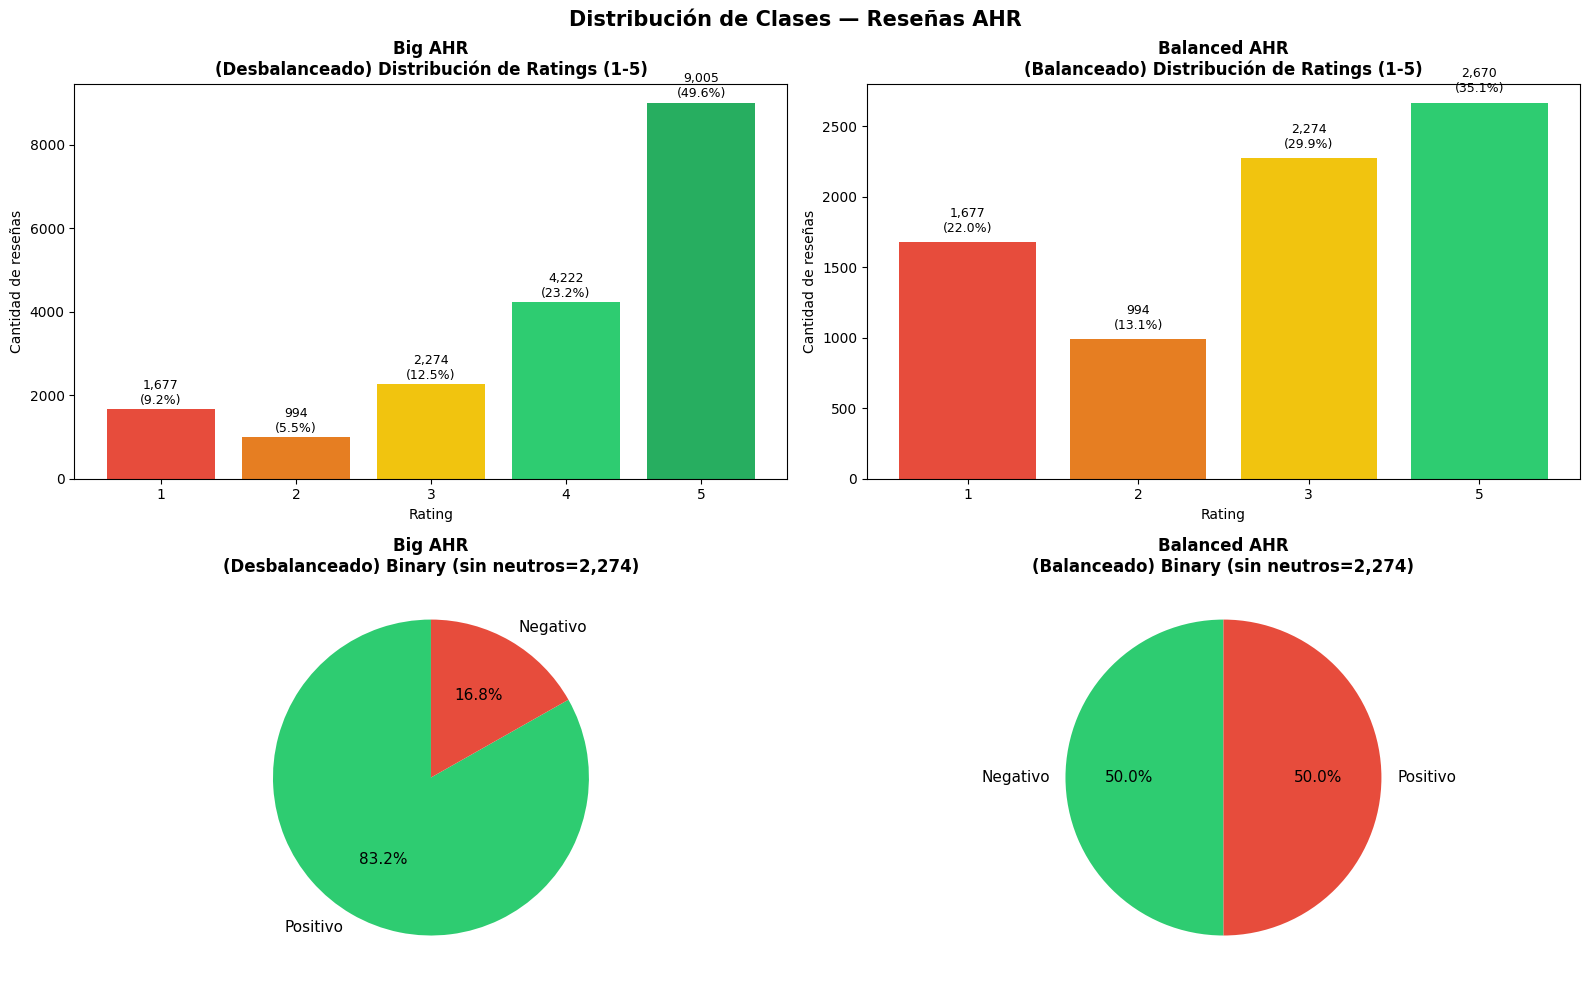

✅ Figura guardada


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Distribución de Clases — Reseñas AHR", fontsize=15, fontweight='bold')

datasets = [("Big AHR\n(Desbalanceado)", df_big),
            ("Balanced AHR\n(Balanceado)",  df_bal)]

for col_idx, (title, df) in enumerate(datasets):
    # ── Distribución de ratings (1-5) ──────────────────────
    ax1 = axes[0][col_idx]
    counts = df['rating'].value_counts().sort_index()
    bars = ax1.bar(counts.index.astype(str), counts.values,
                   color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
    ax1.set_title(f'{title} Distribución de Ratings (1-5)', fontsize=12, fontweight='bold')
    ax1.set_xlabel("Rating")
    ax1.set_ylabel("Cantidad de reseñas")
    for bar, val in zip(bars, counts.values):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

    # ── Distribución de etiquetas binarias (sin neutros) ───
    ax2 = axes[1][col_idx]
    df_bin = df[df['label'] != 3].copy()
    df_bin['sentiment'] = df_bin['label'].map({1: 'Positivo', 0: 'Negativo'})
    vc = df_bin['sentiment'].value_counts()
    ax2.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90, textprops={'fontsize':11})
    ax2.set_title(f'{title} Binary (sin neutros={df[df.label==3].shape[0]:,})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "01_class_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada")

## 5. Estadísticas de Longitud de Texto


==================================================  Big AHR
  [title — número de palabras]
count    18172.00
mean         3.77
std          2.66
min          1.00
25%          2.00
50%          3.00
75%          5.00
max         24.00

  [review_text — número de palabras]
count    18172.00
mean        78.83
std         55.51
min          7.00
25%         42.00
50%         61.00
75%        103.00
max       1416.00

==================================================  Balanced AHR
  [title — número de palabras]
count    7615.00
mean        3.81
std         2.75
min         1.00
25%         2.00
50%         3.00
75%         5.00
max        23.00

  [review_text — número de palabras]
count    7615.00
mean       86.92
std        64.68
min        12.00
25%        44.00
50%        68.00
75%       119.00
max      1416.00


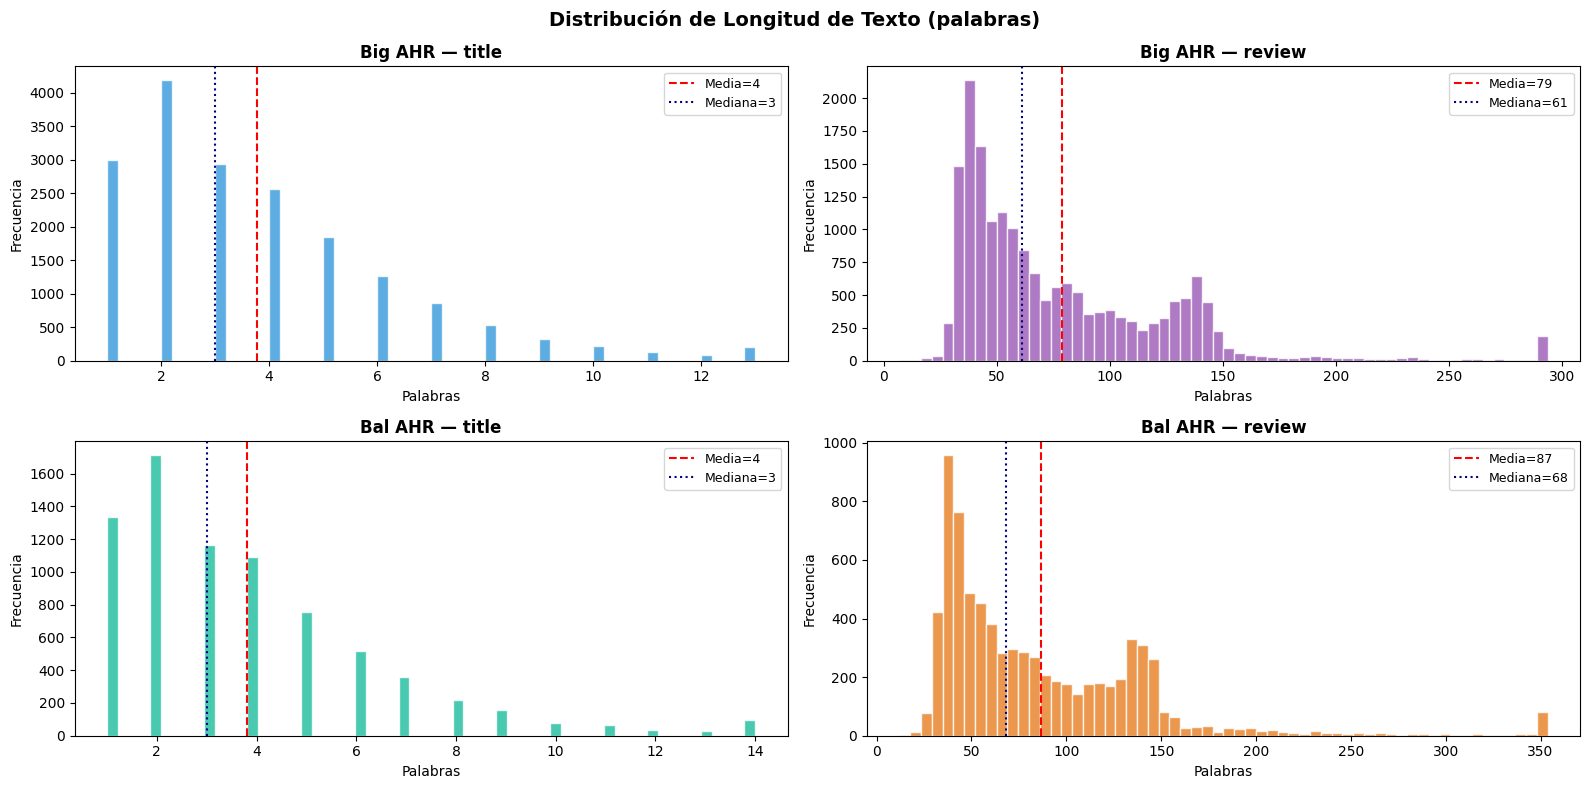

In [10]:
def text_length_stats(df, name):
    df = df.copy()
    df['len_title']  = df['title'].fillna('').apply(lambda x: len(str(x).split()))
    df['len_review'] = df['review_text'].fillna('').apply(lambda x: len(str(x).split()))
    print(f"\n{'='*50}  {name}")
    print("  [title — número de palabras]")
    print(df['len_title'].describe().round(2).to_string())
    print("\n  [review_text — número de palabras]")
    print(df['len_review'].describe().round(2).to_string())
    return df

df_big = text_length_stats(df_big, "Big AHR")
df_bal = text_length_stats(df_bal, "Balanced AHR")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("Distribución de Longitud de Texto (palabras)", fontsize=14, fontweight='bold')

pairs = [
    (df_big, "Big AHR — title",   "len_title",  "#3498db"),
    (df_big, "Big AHR — review",  "len_review", "#9b59b6"),
    (df_bal, "Bal AHR — title",   "len_title",  "#1abc9c"),
    (df_bal, "Bal AHR — review",  "len_review", "#e67e22"),
]
for ax, (df, lbl, col, clr) in zip(axes.flat, pairs):
    data = df[col].clip(0, df[col].quantile(0.99))
    ax.hist(data, bins=60, color=clr, alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(),   color='red',  linestyle='--', label=f'Media={df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='navy', linestyle=':',  label=f'Mediana={df[col].median():.0f}')
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel("Palabras"); ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "02_text_length_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()

## 6. Nube de Palabras

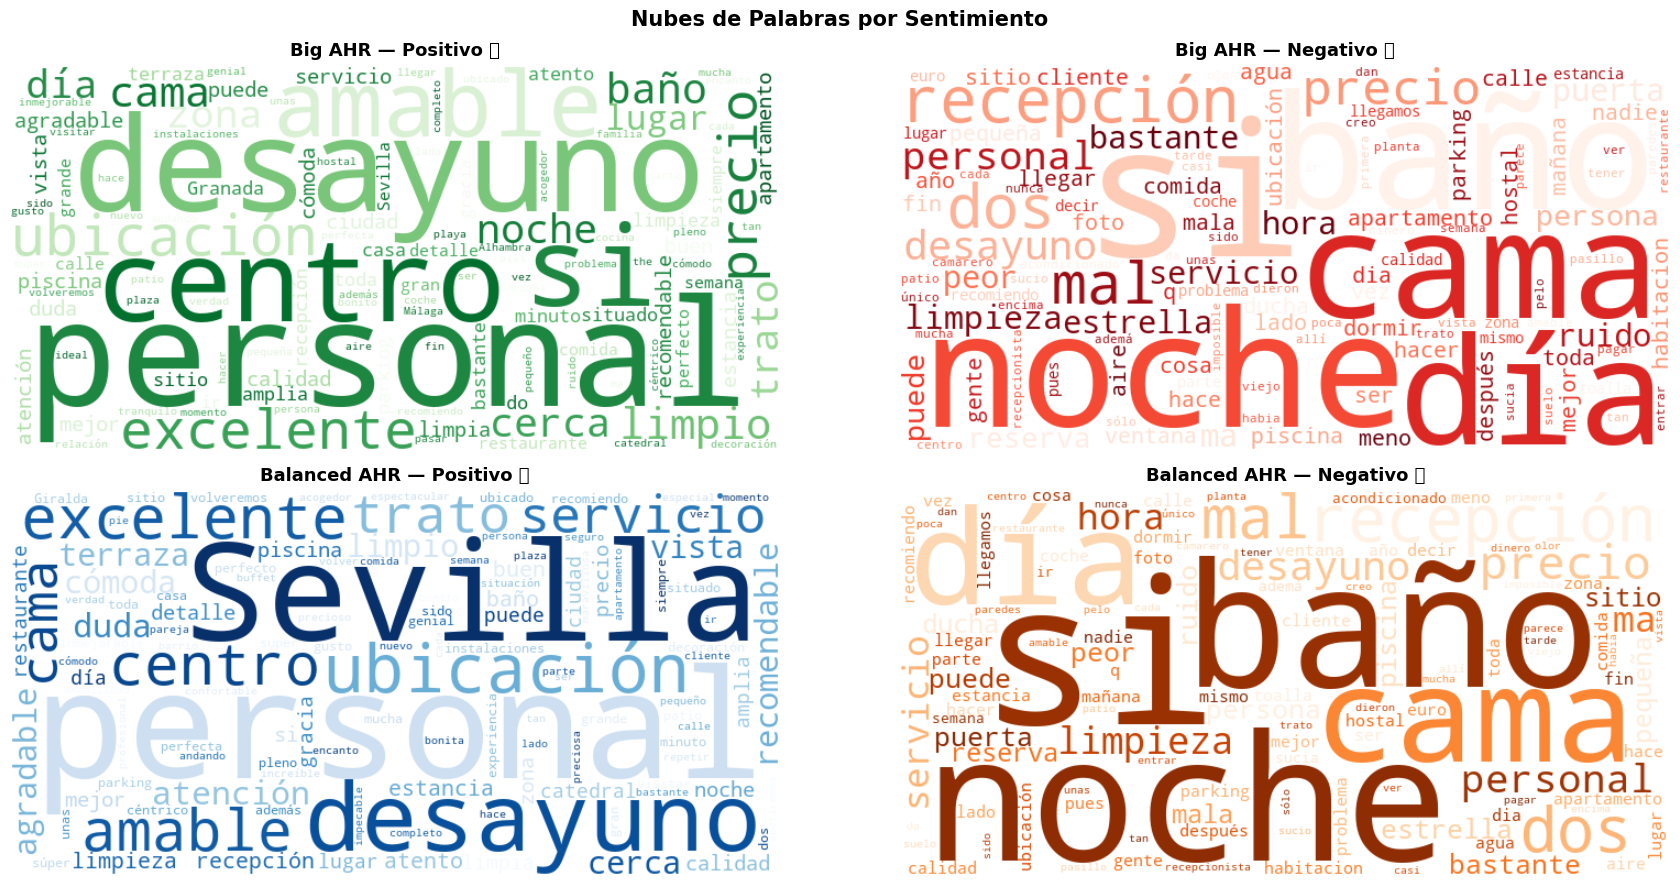

In [11]:
from wordcloud import WordCloud, STOPWORDS

STOP_ES = set(stopwords.words('spanish'))
EXTRA   = {"hotel","hoteles","habitación","habitaciones","muy","más","todo",
           "también","así","aunque","solo","bien","buena","buenas","bueno","buenos"}
STOP_ES.update(EXTRA)

def make_wordcloud(texts, title, color, ax):
    corpus = " ".join(texts.dropna().astype(str).tolist())
    wc = WordCloud(width=700, height=350, background_color='white',
                   stopwords=STOP_ES, colormap=color,
                   max_words=120, collocations=False).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)

df_big_bin = df_big[df_big['label'] != 3].copy()
df_big_bin['sentiment'] = df_big_bin['label'].map({1:'Positivo',0:'Negativo'})

fig, axes = plt.subplots(2, 2, figsize=(18, 9))
fig.suptitle("Nubes de Palabras por Sentimiento", fontsize=15, fontweight='bold')

make_wordcloud(df_big_bin[df_big_bin.sentiment=='Positivo']['review_text'],
               "Big AHR — Positivo ✅", "Greens", axes[0][0])
make_wordcloud(df_big_bin[df_big_bin.sentiment=='Negativo']['review_text'],
               "Big AHR — Negativo ❌", "Reds",   axes[0][1])

df_bal_bin = df_bal[df_bal['label'] != 3].copy()
df_bal_bin['sentiment'] = df_bal_bin['label'].map({1:'Positivo',0:'Negativo'})

make_wordcloud(df_bal_bin[df_bal_bin.sentiment=='Positivo']['review_text'],
               "Balanced AHR — Positivo ✅", "Blues",   axes[1][0])
make_wordcloud(df_bal_bin[df_bal_bin.sentiment=='Negativo']['review_text'],
               "Balanced AHR — Negativo ❌", "Oranges", axes[1][1])

plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "03_wordclouds.png"), dpi=150, bbox_inches='tight')
plt.show()

## 7. Preprocesamiento de Texto

In [12]:
import re

STOP_ES_CLEAN = set(stopwords.words('spanish'))

def clean_text(text):
    """Limpieza de texto en español para clasificación de sentimiento."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)        # URLs
    text = re.sub(r'<.*?>', ' ', text)                    # HTML
    text = re.sub(r'[^a-záéíóúüñ\s]', ' ', text)        # Solo letras + acentos ES
    text = re.sub(r'\s+', ' ', text).strip()             # Espacios múltiples
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_ES_CLEAN and len(t) > 2]
    return " ".join(tokens)

# Combinar title + review_text
def prepare_df(df, name):
    df = df[df['label'] != 3].copy()                      # Eliminar neutros
    df['label_bin'] = df['label'].astype(int)             # 0=neg, 1=pos
    df['combined']  = (df['title'].fillna('') + " " +
                       df['review_text'].fillna(''))
    df['text_clean'] = df['combined'].apply(clean_text)
    df = df[df['text_clean'].str.len() > 10].reset_index(drop=True)
    print(f"✅ {name:20s}: {len(df):>6,} muestras  "
          f"| Pos={df.label_bin.sum():,}  "
          f"| Neg={(df.label_bin==0).sum():,}")
    return df[['text_clean','label_bin','rating']]

df_big_proc = prepare_df(df_big, "Big AHR")
df_bal_proc = prepare_df(df_bal, "Balanced AHR")

✅ Big AHR             : 15,893 muestras  | Pos=13,222  | Neg=2,671
✅ Balanced AHR        :  5,341 muestras  | Pos=2,670  | Neg=2,671


## 8. Tokenización y Padding

In [13]:
# ── Parámetros globales de tokenización ───────────────────
MAX_VOCAB   = 20000    # Tamaño máximo del vocabulario
MAX_LEN     = 150      # Longitud máxima de secuencia (palabras)

def build_tokenizer_and_sequences(df, name, max_vocab=MAX_VOCAB, max_len=MAX_LEN):
    tokenizer = Tokenizer(num_words=max_vocab, oov_token='<OOV>')
    tokenizer.fit_on_texts(df['text_clean'])

    vocab_size = min(max_vocab, len(tokenizer.word_index) + 1)
    print(f"\n{name}")
    print(f"  Vocabulario total    : {len(tokenizer.word_index):,}")
    print(f"  Vocabulario efectivo : {vocab_size:,}")

    seqs    = tokenizer.texts_to_sequences(df['text_clean'])
    padded  = pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
    labels  = df['label_bin'].values

    # Análisis de cobertura OOV
    oov_pct = np.mean([sum(1 for t in s if t == 1) / max(len(s),1) for s in seqs]) * 100
    print(f"  OOV promedio         : {oov_pct:.2f}%")
    print(f"  Shape padded         : {padded.shape}")

    return tokenizer, padded, labels, vocab_size

tok_big, X_big, y_big, vs_big = build_tokenizer_and_sequences(df_big_proc, "Big AHR")
tok_bal, X_bal, y_bal, vs_bal = build_tokenizer_and_sequences(df_bal_proc, "Balanced AHR")


Big AHR
  Vocabulario total    : 29,766
  Vocabulario efectivo : 20,000
  OOV promedio         : 1.22%
  Shape padded         : (15893, 150)

Balanced AHR
  Vocabulario total    : 18,032
  Vocabulario efectivo : 18,033
  OOV promedio         : 0.00%
  Shape padded         : (5341, 150)


## 9. Split Train / Val / Test

In [14]:
def split_data(X, y, seed=SEED):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.2,  random_state=seed, stratify=y)
    X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=seed, stratify=y_tmp)
    return X_tr, X_val, X_te, y_tr, y_val, y_te

X_big_tr,X_big_val,X_big_te,y_big_tr,y_big_val,y_big_te = split_data(X_big, y_big)
X_bal_tr,X_bal_val,X_bal_te,y_bal_tr,y_bal_val,y_bal_te = split_data(X_bal, y_bal)

for name, Xtr, Xva, Xte in [
    ("Big AHR",      X_big_tr, X_big_val, X_big_te),
    ("Balanced AHR", X_bal_tr, X_bal_val, X_bal_te)]:
    print(f"{name:20s}: train={len(Xtr):>5,}  val={len(Xva):>4,}  test={len(Xte):>4,}")

Big AHR             : train=12,714  val=1,589  test=1,590
Balanced AHR        : train=4,272  val= 534  test= 535


## 10. Guardar Artefactos Preprocesados

In [15]:
import pickle as pkl

def save_preprocessed(prefix, tokenizer, vocab_size,
                       X_tr,X_val,X_te, y_tr,y_val,y_te, df_clean):
    base = os.path.join(DIRS["data"], prefix)
    os.makedirs(base, exist_ok=True)

    np.save(f"{base}/X_train.npy", X_tr);  np.save(f"{base}/y_train.npy", y_tr)
    np.save(f"{base}/X_val.npy",   X_val); np.save(f"{base}/y_val.npy",   y_val)
    np.save(f"{base}/X_test.npy",  X_te);  np.save(f"{base}/y_test.npy",  y_te)

    with open(f"{base}/tokenizer.pkl", "wb") as f:
        pkl.dump(tokenizer, f)

    meta = {"vocab_size": int(vocab_size), "max_len": MAX_LEN,
            "train_size": len(X_tr), "val_size": len(X_val), "test_size": len(X_te),
            "pos_train": int(y_tr.sum()), "neg_train": int((y_tr==0).sum())}
    with open(f"{base}/meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    df_clean.to_csv(f"{base}/dataset_clean.csv", index=False)
    print(f"✅ Guardado en {base}/  ({len(X_tr)+len(X_val)+len(X_te):,} muestras totales)")

save_preprocessed("big_ahr",      tok_big, vs_big,
                  X_big_tr, X_big_val, X_big_te,
                  y_big_tr, y_big_val, y_big_te, df_big_proc)
save_preprocessed("balanced_ahr", tok_bal, vs_bal,
                  X_bal_tr, X_bal_val, X_bal_te,
                  y_bal_tr, y_bal_val, y_bal_te, df_bal_proc)

print("\n✅ Preprocesamiento completado. Listo para modelado.")

✅ Guardado en results/data/big_ahr/  (15,893 muestras totales)
✅ Guardado en results/data/balanced_ahr/  (5,341 muestras totales)

✅ Preprocesamiento completado. Listo para modelado.


## 11. Resumen del EDA

In [17]:
print("="*60)
print("  RESUMEN EDA — ANDALUSIAN HOTEL REVIEWS")
print("="*60)
for name, df_proc, meta_path in [
    ("Big AHR (Desbalanceado)", df_big_proc, f"{DIRS['data']}/big_ahr/meta.json"),
    ("Balanced AHR",            df_bal_proc, f"{DIRS['data']}/balanced_ahr/meta.json")]:
    with open(meta_path) as f:
        meta = json.load(f)
    print(f"\n  [{name}]")
    print(f"    Muestras totales  : {len(df_proc):,}")
    print(f"    Positivos         : {df_proc.label_bin.sum():,} ({df_proc.label_bin.mean()*100:.1f}%)")
    print(f"    Negativos         : {(df_proc.label_bin==0).sum():,} ({(1-df_proc.label_bin.mean())*100:.1f}%)")
    print(f"    Vocabulario (eff) : {meta['vocab_size']:,}")
    print(f"    Max longitud seq  : {meta['max_len']}")
    print(f"    Train / Val / Test: {meta['train_size']} / {meta['val_size']} / {meta['test_size']}")


  RESUMEN EDA — ANDALUSIAN HOTEL REVIEWS

  [Big AHR (Desbalanceado)]
    Muestras totales  : 15,893
    Positivos         : 13,222 (83.2%)
    Negativos         : 2,671 (16.8%)
    Vocabulario (eff) : 20,000
    Max longitud seq  : 150
    Train / Val / Test: 12714 / 1589 / 1590

  [Balanced AHR]
    Muestras totales  : 5,341
    Positivos         : 2,670 (50.0%)
    Negativos         : 2,671 (50.0%)
    Vocabulario (eff) : 18,033
    Max longitud seq  : 150
    Train / Val / Test: 4272 / 534 / 535
